## Link Video
### https://drive.google.com/drive/folders/1v1En2xqdBHOVpnJODKBRemMxlZTXfk8y?usp=sharing

# **3. Data Generation using GAN (Modified Model)**

## Import Library

In [ ]:
from zipfile import ZipFile
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import cv2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from matplotlib import pyplot as plt
from tensorflow.keras.layers import Input, Dense, Reshape, Conv2D, Conv2DTranspose, Activation, LeakyReLU, Flatten, MaxPooling2D, UpSampling2D, Cropping2D, BatchNormalization
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.preprocessing.image import array_to_img
from scipy.linalg import sqrtm

## Extract File (Because In Colab)

In [ ]:
zip_path = '/content/B_23.zip'
extract_path = '/content/B_23'

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

def loadFile(folder_path='/content/B_23', size=(100, 100)):
    images = []
    valid_extensions = ('.jpg', '.png', '.jpeg')

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(valid_extensions):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype(np.float32) / 127.5 - 1.0
            images.append(img)

    return np.array(images)

real_images = loadFile()
print("Images loaded:", real_images.shape)

Images loaded: (0,)


## Read Data

In [ ]:
# def loadFile(folder_path='B_23', size=(100, 100)):
#     images = []
#     valid_extensions = ('.jpg', '.png', '.jpeg')

#     for filename in os.listdir(folder_path):
#         if filename.lower().endswith(valid_extensions):
#             img_path = os.path.join(folder_path, filename)
#             img = cv2.imread(img_path)
#             if img is None:
#                 continue

#             img = cv2.resize(img, size)
#             img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#             img = img.astype(np.float32) / 127.5 - 1.0
#             images.append(img)

#     return np.array(images)

In [ ]:
real_images = loadFile('B_23/B_23', size=(100, 100))

## Show Image

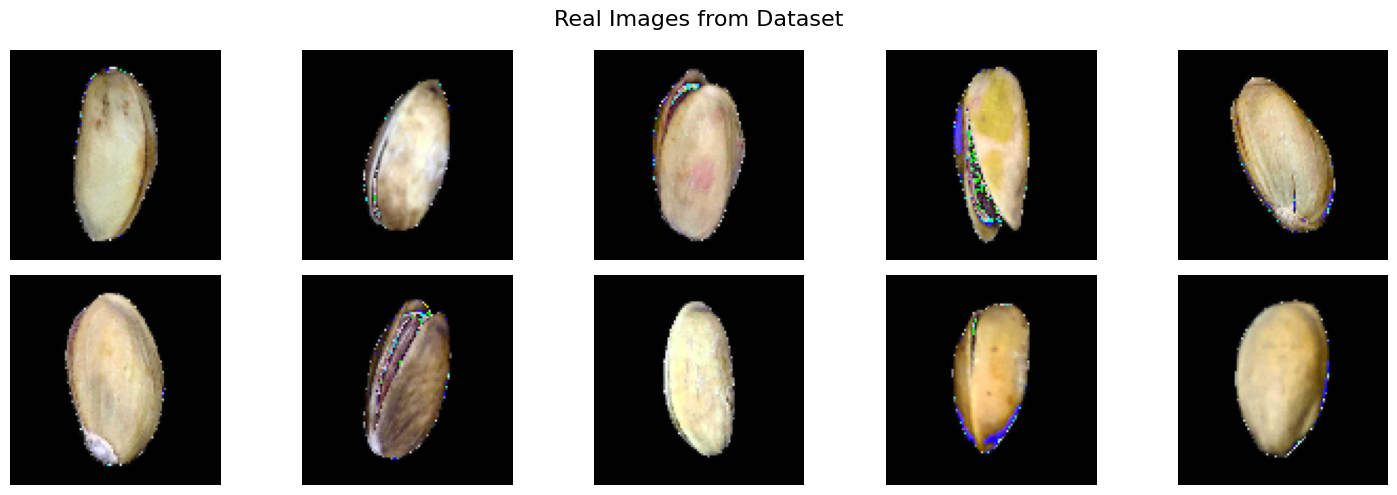

In [ ]:
def plot_real_images(images, num_images=10):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(2, num_images // 2, i + 1)
        img = images[i]
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)

        plt.imshow(img)
        plt.axis('off')

    plt.suptitle('Real Images from Dataset', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_real_images(real_images, num_images=10)

## Generator Model

In [ ]:
def build_generator():
    model = Sequential()

    model.add(Dense(25 * 25 * 256, input_dim=latent_dim))
    model.add(Reshape((25, 25, 256)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Conv2DTranspose(3, kernel_size=3, strides=1, padding='same', activation='tanh'))

    return model

modification ReLu into LeakyReLU gives smoother gradients, then the padding we change into 'same' give spatial size consistent, batchnormalization helps stabilize training, and changging the architecture into 25 x 25 x 128 and upsamples to match size of 100 x 100 more cleanly and efficiently

## Discriminator Model

In [ ]:
def build_discriminator():
    model = Sequential()

    model.add(Conv2D(32, kernel_size=3, strides=2, padding='same', input_shape=(128, 128, 3)))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))

    model.add(Conv2D(64, kernel_size=3, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))

    model.add(Conv2D(128, kernel_size=3, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model

changging the ReLU with LeakyReLU same like generator, then adding dropout to prevent discriminator from overfitting, then strides into 2 for learnable weights with padding change into 'same' to maintains spatial shape better during conv layers, then changging the channels into 64 -> 128 -> 256 for more powerful discriminator to handle higher resolution images

In [ ]:
class CustomGAN(tf.keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.disc = discriminator
        self.gen = generator
        self.latent_dim = latent_dim

    def compile(self, disc_optimizer, gen_optimizer, loss_function):
        super().compile()
        self.d_opt = disc_optimizer
        self.g_opt = gen_optimizer
        self.loss_fn = loss_function
        self.d_loss_tracker = tf.keras.metrics.Mean(name="disc_loss")
        self.g_loss_tracker = tf.keras.metrics.Mean(name="gen_loss")

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def train_step(self, real_data):
        batch_size = tf.shape(real_data)[0]
        noise = tf.random.normal(shape=(batch_size, self.latent_dim))

        with tf.GradientTape() as tape:
            generated = self.gen(noise, training=True)
            real_pred = self.disc(real_data, training=True)
            fake_pred = self.disc(generated, training=True)

            real_labels = tf.ones_like(real_pred) * 0.9
            fake_labels = tf.zeros_like(fake_pred)

            d_loss_real = self.loss_fn(real_labels, real_pred)
            d_loss_fake = self.loss_fn(fake_labels, fake_pred)
            d_loss = d_loss_real + d_loss_fake
        disc_grads = tape.gradient(d_loss, self.disc.trainable_weights)
        self.d_opt.apply_gradients(zip(disc_grads, self.disc.trainable_weights))

        noise = tf.random.normal(shape=(batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            gen_imgs = self.gen(noise, training=True)
            disc_pred = self.disc(gen_imgs, training=True)
            g_loss = self.loss_fn(tf.ones_like(disc_pred), disc_pred)

        gen_grads = tape.gradient(g_loss, self.gen.trainable_weights)
        self.g_opt.apply_gradients(zip(gen_grads, self.gen.trainable_weights))

        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)

        return {
            "disc_loss": self.d_loss_tracker.result(),
            "gen_loss": self.g_loss_tracker.result(),
        }

In [ ]:
class GANSnapshotCallback(tf.keras.callbacks.Callback):
    def __init__(self, num_samples=5, latent_dim=100, save_every=10):
        super().__init__()
        self.num_samples = num_samples
        self.latent_dim = latent_dim
        self.save_every = save_every
        self.fixed_noise = tf.random.normal([self.num_samples, self.latent_dim])

        self.g_losses = []
        self.d_losses = []

        self.output_dir = "epoch_generated_images"
        os.makedirs(self.output_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        self.d_losses.append(logs.get('d_loss'))
        self.g_losses.append(logs.get('g_loss'))

        if (epoch + 1) % self.save_every == 0:
            fake_images = self.model.gen(self.fixed_noise, training=False)
            fake_images = (fake_images + 1.0) / 2.0

            fig, axes = plt.subplots(1, self.num_samples, figsize=(15, 3))
            fig.suptitle(f"Generated Samples at Epoch {epoch + 1}", fontsize=14)

            for i in range(self.num_samples):
                axes[i].imshow(fake_images[i])
                axes[i].axis('off')

            plt.show()
            plt.close()

In [ ]:
class FIDCallback(tf.keras.callbacks.Callback):
    def __init__(self, real_images, noise_dim=100, sample_size=100, save_every=25):
        super().__init__()
        self.real_images = real_images[:sample_size].astype(np.float32)
        if self.real_images.max() > 1.0:
            self.real_images = self.real_images / 255.0
        self.latent_dim = latent_dim
        self.sample_size = sample_size
        self.save_every = save_every
        self.inception = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

    def calculate_fid(self, real_images, fake_images):
        real_resized = np.array([cv2.resize(img, (299, 299)) for img in real_images])
        fake_resized = np.array([cv2.resize(img, (299, 299)) for img in fake_images])

        real_resized = preprocess_input(real_resized.astype(np.float32))
        fake_resized = preprocess_input(fake_resized.astype(np.float32))

        act1 = self.inception.predict(real_resized, batch_size=32, verbose=0)
        act2 = self.inception.predict(fake_resized, batch_size=32, verbose=0)

        mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
        mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
        diff = mu1 - mu2
        covmean, _ = sqrtm(sigma1 @ sigma2, disp=False)

        if np.iscomplexobj(covmean):
            covmean = covmean.real

        return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.save_every == 0:
            noise = tf.random.normal((self.sample_size, self.latent_dim))
            generated = self.model.gen(noise, training=False)
            generated = (generated + 1) / 2.0
            fid = self.calculate_fid(self.real_images, generated.numpy())
            print(f"\nFID at epoch {epoch+1}: {fid:.2f}")

## Build Model

In [ ]:
noise_dim = 100
generator = build_generator()
discriminator = build_discriminator()

gen_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

gan = CustomGAN(discriminator, generator, noise_dim)
gan.compile(
    disc_optimizer=disc_optimizer,
    gen_optimizer=gen_optimizer,
    loss_function=tf.keras.losses.BinaryCrossentropy()
)

NameError: name 'build_generator' is not defined

## Preprocess Image

In [ ]:
real_images = loadFile('B_23/B_23', size=(100, 100))
print(real_images.shape)

(1074, 100, 100, 3)


Epoch 1/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - disc_loss: 1.3668 - gen_loss: 0.8283
Epoch 2/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - disc_loss: 1.3605 - gen_loss: 0.8234
Epoch 3/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - disc_loss: 1.3667 - gen_loss: 0.8251
Epoch 4/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - disc_loss: 1.3678 - gen_loss: 0.8085
Epoch 5/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - disc_loss: 1.3708 - gen_loss: 0.8136
Epoch 6/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - disc_loss: 1.3749 - gen_loss: 0.7991
Epoch 7/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - disc_loss: 1.3718 - gen_loss: 0.8096
Epoch 8/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - disc_loss: 1.3728 - gen_loss: 0.8137
Epoch 9/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - disc_loss: 1.3615 - gen_loss: 0.8460
Epoch 10/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - disc_loss: 1.3609 - gen_loss: 0.8191
Epoch 11/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.3550 - gen

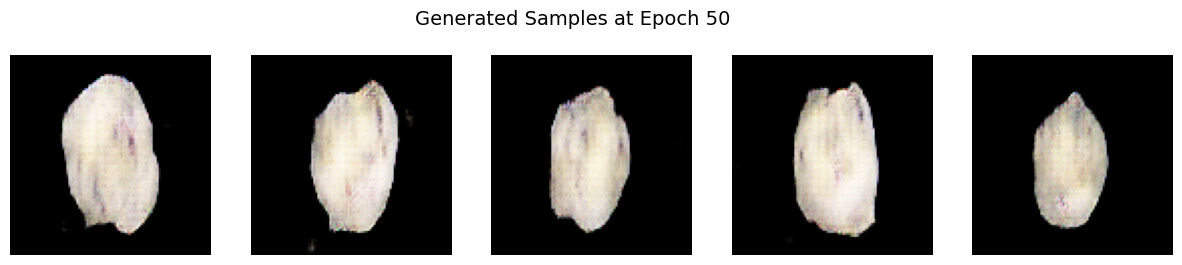


FID at epoch 50: 115.98
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 300ms/step - disc_loss: 1.3604 - gen_loss: 0.8370
Epoch 51/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3690 - gen_loss: 0.8241
Epoch 52/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3632 - gen_loss: 0.8219
Epoch 53/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3653 - gen_loss: 0.8303
Epoch 54/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3671 - gen_loss: 0.8323
Epoch 55/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3577 - gen_loss: 0.8568
Epoch 56/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.3674 - gen_loss: 0.8771
Epoch 57/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3431 - gen_loss: 0.8633
Epoch 58/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3704 - gen_loss: 0.8054
Epoch 59/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3650 - gen_loss: 0.8273
Epoch 60/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - d

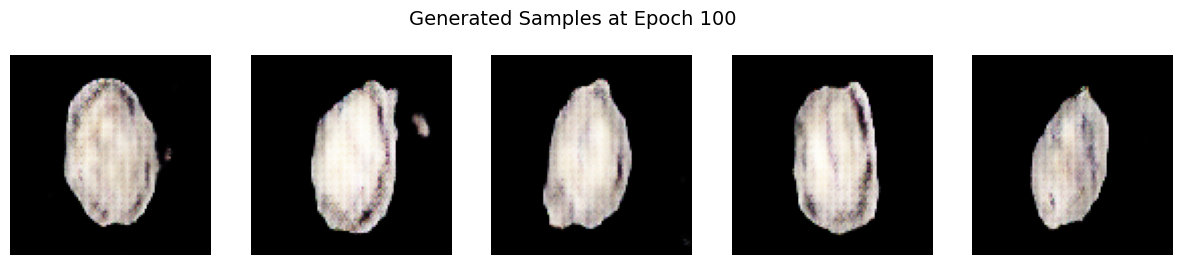


FID at epoch 100: 111.03
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 282ms/step - disc_loss: 1.3743 - gen_loss: 0.8231
Epoch 101/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.3424 - gen_loss: 0.8434
Epoch 102/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.3678 - gen_loss: 0.8424
Epoch 103/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3502 - gen_loss: 0.8382
Epoch 104/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.3436 - gen_loss: 0.8388
Epoch 105/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.3686 - gen_loss: 0.8213
Epoch 106/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.3598 - gen_loss: 0.8421
Epoch 107/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3705 - gen_loss: 0.8413
Epoch 108/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3527 - gen_loss: 0.8568
Epoch 109/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3521 - gen_loss: 0.8329
Epoch 110/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46

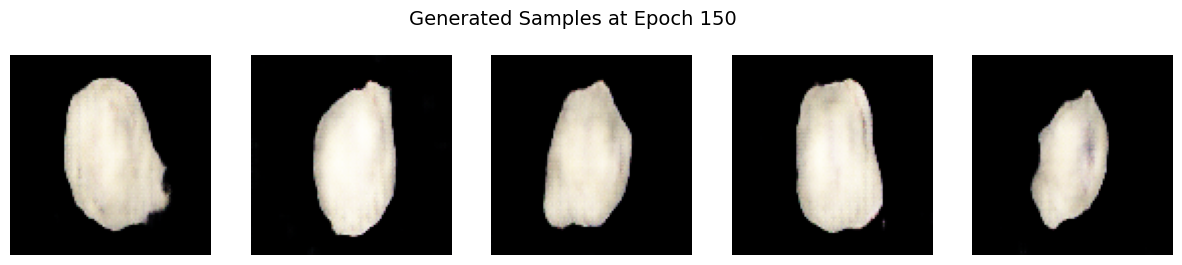


FID at epoch 150: 116.14
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 278ms/step - disc_loss: 1.3639 - gen_loss: 0.8646
Epoch 151/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3211 - gen_loss: 0.8694
Epoch 152/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.3477 - gen_loss: 0.8404
Epoch 153/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3425 - gen_loss: 0.8420
Epoch 154/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3524 - gen_loss: 0.8403
Epoch 155/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3787 - gen_loss: 0.8198
Epoch 156/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.3392 - gen_loss: 0.8571
Epoch 157/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3422 - gen_loss: 0.8339
Epoch 158/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3569 - gen_loss: 0.8621
Epoch 159/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3480 - gen_loss: 0.8530
Epoch 160/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46

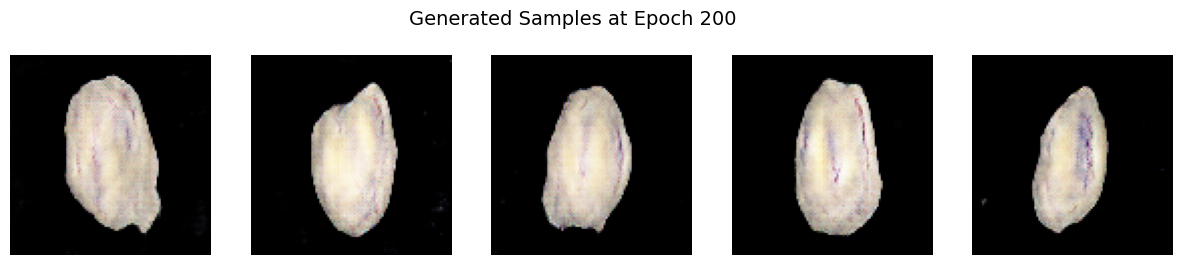


FID at epoch 200: 117.74
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 264ms/step - disc_loss: 1.3303 - gen_loss: 0.8550
Epoch 201/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3092 - gen_loss: 1.0134
Epoch 202/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3564 - gen_loss: 0.8826
Epoch 203/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3281 - gen_loss: 0.8661
Epoch 204/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3464 - gen_loss: 0.8570
Epoch 205/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3359 - gen_loss: 0.8483
Epoch 206/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3671 - gen_loss: 0.8447
Epoch 207/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.3291 - gen_loss: 0.8823
Epoch 208/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3694 - gen_loss: 0.8612
Epoch 209/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3351 - gen_loss: 0.8682
Epoch 210/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46

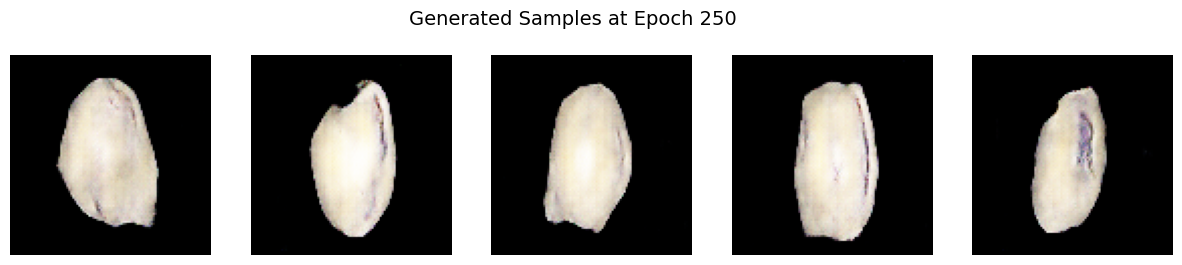


FID at epoch 250: 113.22
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 280ms/step - disc_loss: 1.3311 - gen_loss: 0.8701
Epoch 251/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3347 - gen_loss: 0.8464
Epoch 252/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.3355 - gen_loss: 0.8474
Epoch 253/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - disc_loss: 1.3335 - gen_loss: 0.8561
Epoch 254/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3351 - gen_loss: 0.8732
Epoch 255/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3362 - gen_loss: 0.8715
Epoch 256/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3388 - gen_loss: 0.8573
Epoch 257/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - disc_loss: 1.3627 - gen_loss: 0.8616
Epoch 258/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3308 - gen_loss: 0.8730
Epoch 259/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3371 - gen_loss: 0.8756
Epoch 260/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47

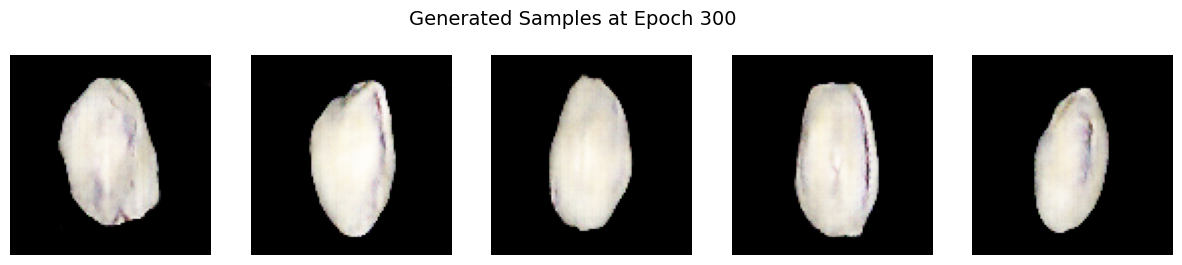


FID at epoch 300: 110.62
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 281ms/step - disc_loss: 1.3235 - gen_loss: 0.8723
Epoch 301/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.3306 - gen_loss: 0.8662
Epoch 302/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3228 - gen_loss: 0.8835
Epoch 303/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - disc_loss: 1.3333 - gen_loss: 0.8888
Epoch 304/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3351 - gen_loss: 0.8705
Epoch 305/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3106 - gen_loss: 0.8968
Epoch 306/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3376 - gen_loss: 0.8777
Epoch 307/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3408 - gen_loss: 0.8574
Epoch 308/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.3160 - gen_loss: 0.8639
Epoch 309/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3292 - gen_loss: 0.8836
Epoch 310/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47

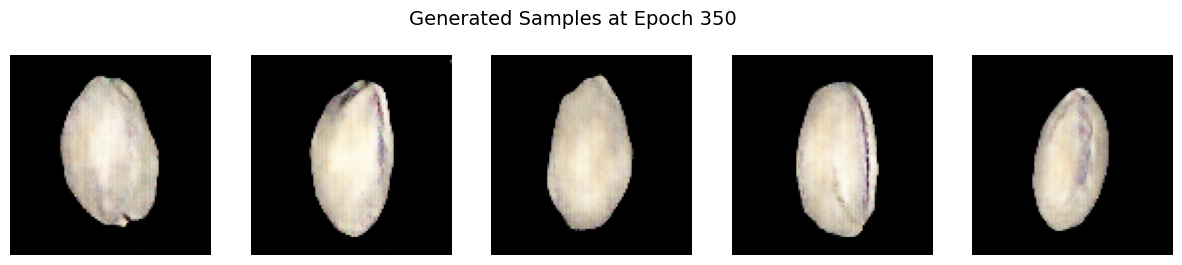


FID at epoch 350: 117.02
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 271ms/step - disc_loss: 1.3388 - gen_loss: 0.8610
Epoch 351/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.3246 - gen_loss: 0.8944
Epoch 352/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.3203 - gen_loss: 0.8901
Epoch 353/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3229 - gen_loss: 0.8943
Epoch 354/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3174 - gen_loss: 0.8897
Epoch 355/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3264 - gen_loss: 0.8967
Epoch 356/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.3228 - gen_loss: 0.8632
Epoch 357/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3340 - gen_loss: 0.8845
Epoch 358/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.3113 - gen_loss: 0.8803
Epoch 359/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3206 - gen_loss: 0.8658
Epoch 360/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46

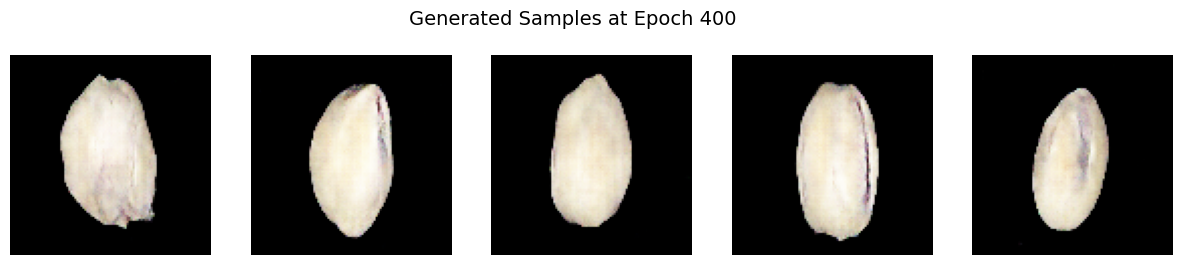


FID at epoch 400: 109.42
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 269ms/step - disc_loss: 1.3323 - gen_loss: 0.8996
Epoch 401/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - disc_loss: 1.3239 - gen_loss: 0.8964
Epoch 402/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2893 - gen_loss: 0.8829
Epoch 403/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - disc_loss: 1.3066 - gen_loss: 0.9108
Epoch 404/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.3180 - gen_loss: 0.8980
Epoch 405/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3254 - gen_loss: 0.9050
Epoch 406/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3045 - gen_loss: 0.9156
Epoch 407/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3100 - gen_loss: 0.9151
Epoch 408/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3015 - gen_loss: 0.8904
Epoch 409/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3214 - gen_loss: 0.9000
Epoch 410/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46

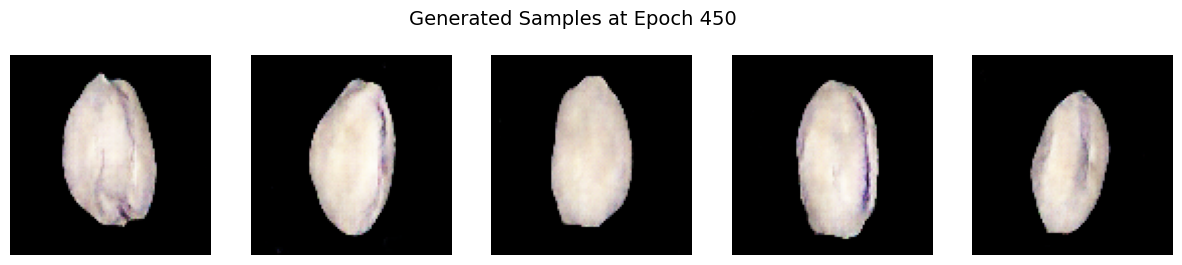


FID at epoch 450: 113.27
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 282ms/step - disc_loss: 1.3007 - gen_loss: 0.9310
Epoch 451/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - disc_loss: 1.3083 - gen_loss: 0.9165
Epoch 452/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2830 - gen_loss: 0.9076
Epoch 453/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3067 - gen_loss: 0.9057
Epoch 454/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2932 - gen_loss: 0.9092
Epoch 455/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.3004 - gen_loss: 0.8922
Epoch 456/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.3072 - gen_loss: 0.8991
Epoch 457/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3112 - gen_loss: 0.9220
Epoch 458/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.3059 - gen_loss: 0.9031
Epoch 459/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2904 - gen_loss: 0.9158
Epoch 460/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47

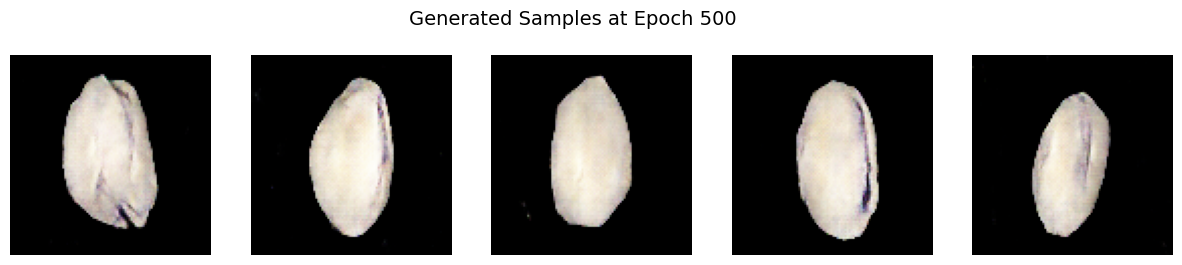


FID at epoch 500: 111.48
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 265ms/step - disc_loss: 1.2964 - gen_loss: 0.9212
Epoch 501/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - disc_loss: 1.3019 - gen_loss: 0.9051
Epoch 502/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3131 - gen_loss: 0.9381
Epoch 503/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2767 - gen_loss: 0.9273
Epoch 504/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2912 - gen_loss: 0.9307
Epoch 505/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.3261 - gen_loss: 0.9182
Epoch 506/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - disc_loss: 1.2986 - gen_loss: 0.9167
Epoch 507/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.3166 - gen_loss: 0.9411
Epoch 508/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.3221 - gen_loss: 0.9299
Epoch 509/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2881 - gen_loss: 0.9610
Epoch 510/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46

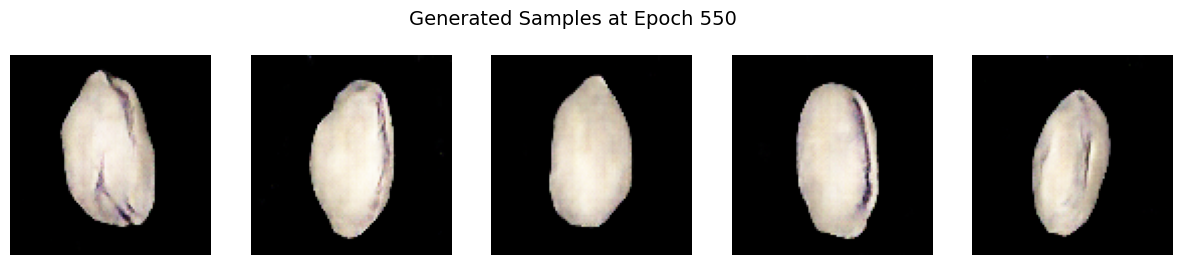


FID at epoch 550: 113.50
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 273ms/step - disc_loss: 1.2898 - gen_loss: 0.9409
Epoch 551/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2709 - gen_loss: 0.9364
Epoch 552/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - disc_loss: 1.2973 - gen_loss: 0.9515
Epoch 553/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2874 - gen_loss: 0.9234
Epoch 554/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2623 - gen_loss: 0.9908
Epoch 555/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.3218 - gen_loss: 0.9496
Epoch 556/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2874 - gen_loss: 0.9614
Epoch 557/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2820 - gen_loss: 0.9284
Epoch 558/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2729 - gen_loss: 0.9435
Epoch 559/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2835 - gen_loss: 0.9600
Epoch 560/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47

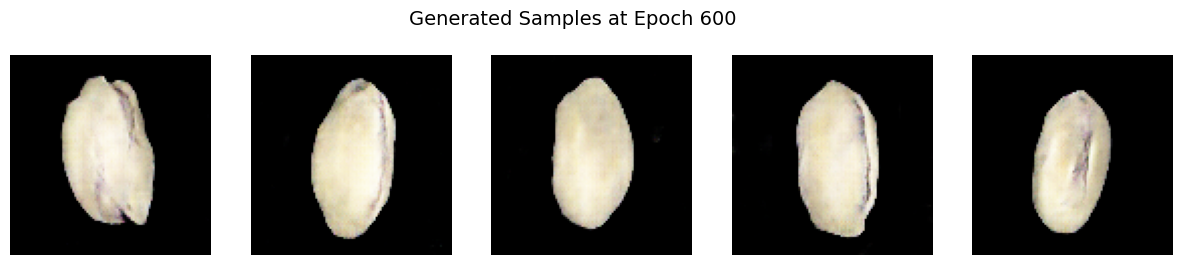


FID at epoch 600: 113.05
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 271ms/step - disc_loss: 1.2564 - gen_loss: 0.9695
Epoch 601/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2840 - gen_loss: 0.9706
Epoch 602/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2837 - gen_loss: 0.9468
Epoch 603/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2821 - gen_loss: 0.9623
Epoch 604/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2689 - gen_loss: 0.9830
Epoch 605/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2795 - gen_loss: 0.9535
Epoch 606/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.2838 - gen_loss: 0.9712
Epoch 607/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2667 - gen_loss: 0.9350
Epoch 608/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2784 - gen_loss: 0.9560
Epoch 609/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2525 - gen_loss: 0.9640
Epoch 610/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46

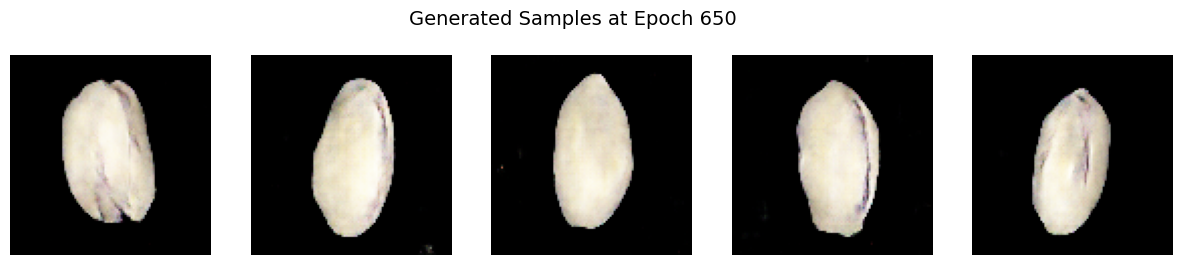


FID at epoch 650: 113.03
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 276ms/step - disc_loss: 1.2746 - gen_loss: 0.9878
Epoch 651/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2630 - gen_loss: 0.9622
Epoch 652/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2875 - gen_loss: 0.9739
Epoch 653/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2457 - gen_loss: 0.9614
Epoch 654/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2904 - gen_loss: 0.9833
Epoch 655/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.2809 - gen_loss: 0.9870
Epoch 656/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2980 - gen_loss: 0.9775
Epoch 657/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.2784 - gen_loss: 0.9831
Epoch 658/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - disc_loss: 1.2713 - gen_loss: 0.9948
Epoch 659/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2838 - gen_loss: 0.9759
Epoch 660/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47

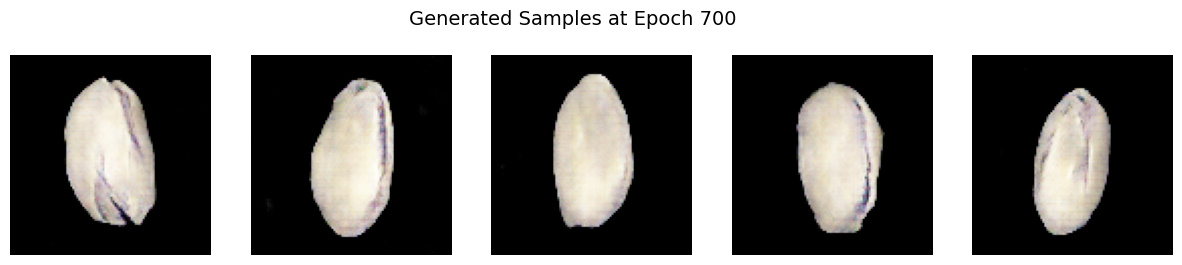


FID at epoch 700: 111.02
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 284ms/step - disc_loss: 1.2706 - gen_loss: 1.0171
Epoch 701/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2435 - gen_loss: 1.0056
Epoch 702/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2563 - gen_loss: 0.9958
Epoch 703/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2731 - gen_loss: 1.0033
Epoch 704/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2866 - gen_loss: 1.0000
Epoch 705/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2655 - gen_loss: 0.9742
Epoch 706/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.2867 - gen_loss: 1.0208
Epoch 707/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.2493 - gen_loss: 0.9759
Epoch 708/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2835 - gen_loss: 0.9843
Epoch 709/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2586 - gen_loss: 0.9886
Epoch 710/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47

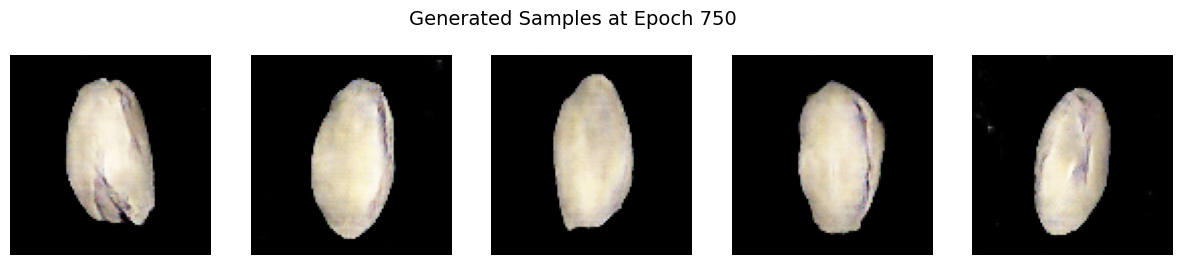


FID at epoch 750: 114.40
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 273ms/step - disc_loss: 1.2770 - gen_loss: 1.0019
Epoch 751/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2616 - gen_loss: 1.0198
Epoch 752/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2722 - gen_loss: 0.9916
Epoch 753/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2624 - gen_loss: 1.0103
Epoch 754/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2575 - gen_loss: 1.0238
Epoch 755/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.2790 - gen_loss: 0.9833
Epoch 756/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - disc_loss: 1.2381 - gen_loss: 1.0140
Epoch 757/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.2545 - gen_loss: 1.0073
Epoch 758/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2555 - gen_loss: 0.9897
Epoch 759/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2585 - gen_loss: 1.0077
Epoch 760/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47

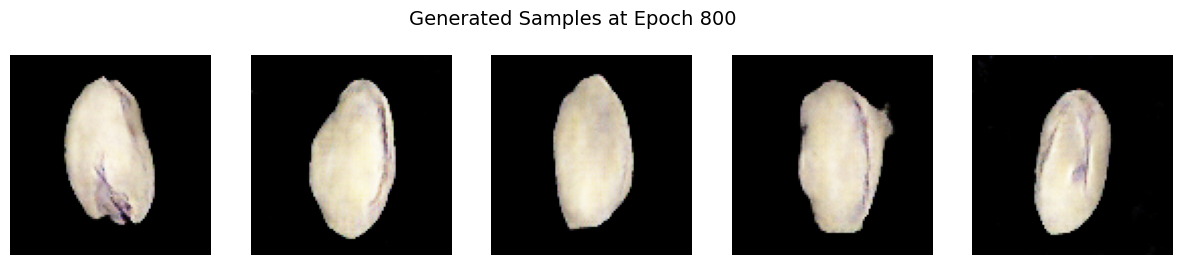


FID at epoch 800: 110.12
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 284ms/step - disc_loss: 1.2552 - gen_loss: 1.0372
Epoch 801/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2639 - gen_loss: 1.0239
Epoch 802/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2553 - gen_loss: 1.0040
Epoch 803/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2440 - gen_loss: 1.0139
Epoch 804/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2817 - gen_loss: 1.0013
Epoch 805/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.2498 - gen_loss: 1.0179
Epoch 806/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2577 - gen_loss: 0.9987
Epoch 807/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2479 - gen_loss: 0.9844
Epoch 808/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2908 - gen_loss: 1.0185
Epoch 809/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2508 - gen_loss: 1.0226
Epoch 810/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46

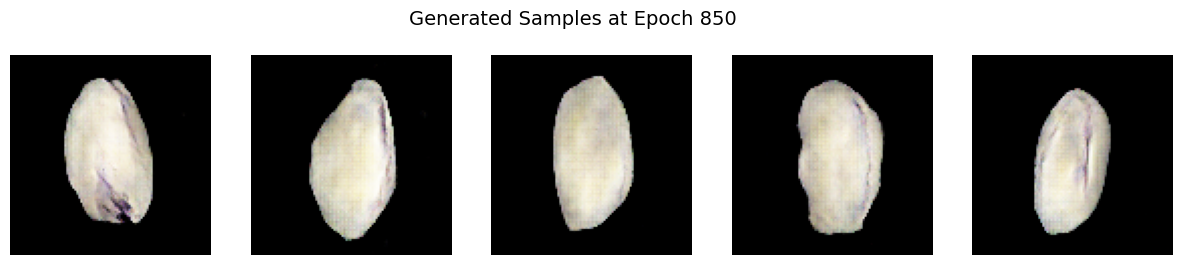


FID at epoch 850: 113.83
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 281ms/step - disc_loss: 1.2515 - gen_loss: 1.0532
Epoch 851/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - disc_loss: 1.2438 - gen_loss: 1.0482
Epoch 852/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - disc_loss: 1.2491 - gen_loss: 1.0296
Epoch 853/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - disc_loss: 1.2518 - gen_loss: 1.0353
Epoch 854/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2712 - gen_loss: 1.0199
Epoch 855/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2486 - gen_loss: 1.0608
Epoch 856/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2431 - gen_loss: 1.0388
Epoch 857/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.2679 - gen_loss: 0.9978
Epoch 858/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2635 - gen_loss: 1.0293
Epoch 859/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2385 - gen_loss: 1.0060
Epoch 860/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46

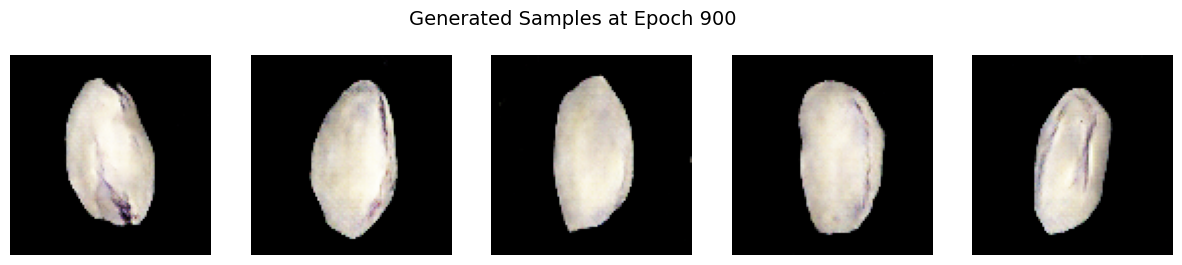


FID at epoch 900: 109.31
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 274ms/step - disc_loss: 1.2357 - gen_loss: 1.0286
Epoch 901/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2510 - gen_loss: 1.0381
Epoch 902/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2290 - gen_loss: 1.0407
Epoch 903/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2494 - gen_loss: 1.0573
Epoch 904/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2361 - gen_loss: 1.0362
Epoch 905/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2541 - gen_loss: 1.0417
Epoch 906/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2607 - gen_loss: 1.0407
Epoch 907/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - disc_loss: 1.2581 - gen_loss: 1.0672
Epoch 908/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - disc_loss: 1.2469 - gen_loss: 1.0348
Epoch 909/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2181 - gen_loss: 1.0576
Epoch 910/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46

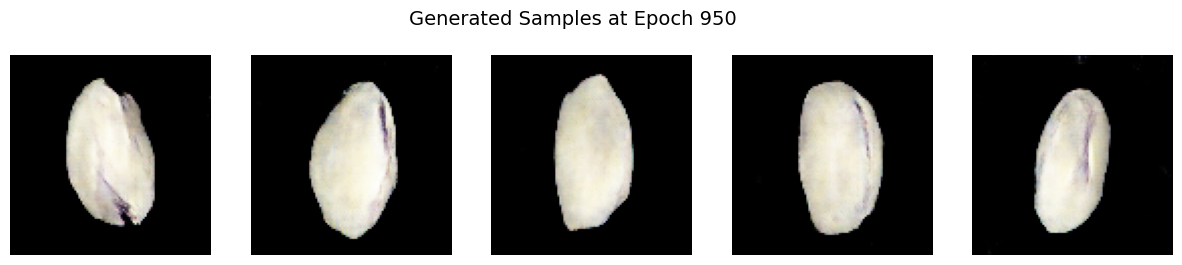


FID at epoch 950: 112.47
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 272ms/step - disc_loss: 1.2615 - gen_loss: 1.0660
Epoch 951/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - disc_loss: 1.2761 - gen_loss: 1.0698
Epoch 952/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2580 - gen_loss: 1.0585
Epoch 953/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2277 - gen_loss: 1.0478
Epoch 954/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2450 - gen_loss: 1.0544
Epoch 955/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2713 - gen_loss: 1.0263
Epoch 956/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2563 - gen_loss: 1.0374
Epoch 957/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - disc_loss: 1.2025 - gen_loss: 1.1027
Epoch 958/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - disc_loss: 1.2807 - gen_loss: 1.0327
Epoch 959/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - disc_loss: 1.2725 - gen_loss: 1.0960
Epoch 960/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45

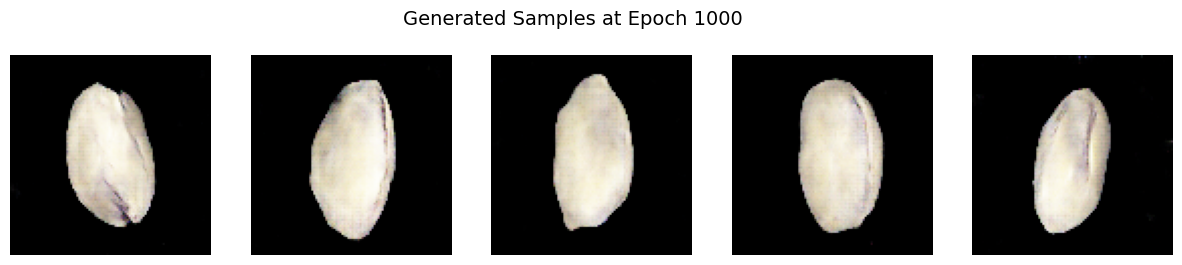


FID at epoch 1000: 108.95
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 276ms/step - disc_loss: 1.2178 - gen_loss: 1.0629


In [ ]:
monitor = GANSnapshotCallback(num_samples=5, latent_dim=noise_dim, save_every=50)
fid_callback = FIDCallback(real_images=real_images, noise_dim=100, sample_size=100, save_every=25)

gan.fit(
    real_images,
    epochs=1000,
    batch_size=16,
    callbacks=[monitor, fid_callback]
)

## Evaluate Modify Model

In [ ]:
inception_model = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

def calculate_fid(model, real_images, fake_images):
    real_resized = np.array([cv2.resize(img, (299, 299)) for img in real_images])
    fake_resized = np.array([cv2.resize(img, (299, 299)) for img in fake_images])

    real_resized = preprocess_input(real_resized.astype(np.float32))
    fake_resized = preprocess_input(fake_resized.astype(np.float32))

    act1 = model.predict(real_resized, batch_size=32, verbose=0)
    act2 = model.predict(fake_resized, batch_size=32, verbose=0)

    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = sqrtm(sigma1 @ sigma2, disp=False)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)

def evaluate_modified_fid(generator, real_images, noise_dim=100, sample_size=1000):
    real_images_sample = real_images[:sample_size].astype(np.float32)
    if real_images_sample.max() > 1.0:
        real_images_sample = real_images_sample / 255.0

    noise = np.random.normal(0, 1, (sample_size, noise_dim))
    gen_imgs = generator.predict(noise, batch_size=32, verbose=0)
    gen_imgs = 0.5 * gen_imgs + 0.5  # [-1,1] → [0,1]

    fid = calculate_fid(inception_model, real_images_sample, gen_imgs)
    print(f"FID Score (Modified Generator): {fid:.2f}")
    return fid

In [ ]:
# call function evaluate
evaluate_modified_fid(generator, real_images)

FID Score (Modified Generator): 110.62


np.float64(110.61510276780655)

Modified 4 retained the configuration of Modified 3 but extended the training to 1000 epochs. This change slightly improved the FID to 110, but the gain was marginal. This result indicates that merely increasing the training duration does not necessarily yield better generative performance, especially when the model architecture remains unchanged and possibly underpowered.